In [19]:
import os
import torch

from matplotlib import pyplot as plt

import numpy as np

In [12]:
dim = 45
scale = 0.2
mean = torch.randn(dim) * 0.1

random_mat = torch.rand(dim, dim) - 0.5 
triu = torch.triu(random_mat)
random_mat = triu + triu.T - torch.eye(dim) * triu * 2 
random_mat *= scale

random_mat += torch.eye(dim) * ( 1 + torch.rand(dim, dim) * scale )

random_mat, mean

(tensor([[ 1.0882,  0.0990, -0.0555,  ...,  0.0655,  0.0145,  0.0792],
         [ 0.0990,  1.0944, -0.0432,  ...,  0.0285, -0.0848,  0.0775],
         [-0.0555, -0.0432,  1.0718,  ..., -0.0521,  0.0181, -0.0942],
         ...,
         [ 0.0655,  0.0285, -0.0521,  ...,  1.1163,  0.0264,  0.0348],
         [ 0.0145, -0.0848,  0.0181,  ...,  0.0264,  1.0828, -0.0560],
         [ 0.0792,  0.0775, -0.0942,  ...,  0.0348, -0.0560,  1.0374]]),
 tensor([-0.0530,  0.0330,  0.0263, -0.0709,  0.0277,  0.0153, -0.0643, -0.0596,
         -0.0373, -0.0044,  0.1562,  0.1669,  0.0427, -0.0602,  0.0165, -0.0185,
         -0.0220, -0.0697, -0.0003, -0.0381,  0.1531,  0.0879,  0.0667,  0.1856,
          0.0067,  0.2232, -0.0152,  0.1148, -0.0570, -0.0028,  0.0377,  0.0078,
         -0.0873,  0.0795, -0.1271, -0.0302, -0.0126,  0.0460,  0.0691, -0.0374,
         -0.0663,  0.1446, -0.0330,  0.0257, -0.1372]))

In [3]:
q0 = torch.distributions.MultivariateNormal(mean, covariance_matrix=random_mat)

In [4]:
# torch.save(mean, "mean.pt")
# torch.save(random_mat, "covariance_matrix.pt")

In [5]:
q0.log_prob(q0.sample((1000000,))).mean()

tensor(-64.2922)

In [6]:
q1 = torch.distributions.MultivariateNormal(torch.zeros(dim), covariance_matrix=torch.eye(dim))

q1.log_prob(q1.sample((1000000,))).mean()

tensor(-63.8498)

In [7]:
dim * torch.log(2*torch.tensor(torch.pi)) / 2 + 1/2 * torch.logdet(random_mat) + 45/2

tensor(64.2926)

In [8]:
dim * torch.log(2*torch.tensor(torch.pi)) / 2  + 45/2

tensor(63.8522)

In [21]:
s = q0.sample((1000000,))

log_dr = q0.log_prob(s) - q1.log_prob(s)


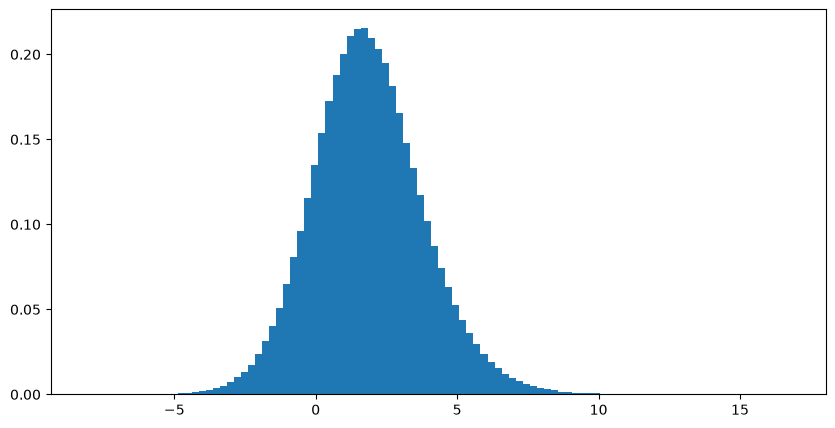

In [23]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(log_dr.cpu().numpy(), bins=100, density=True)

plt.show()

In [24]:
log_dr.mean()

tensor(1.8663)